# The Geometry of Linear Systems

**This notebook teaches linear systems from scratch, no prior exposure is assumed.**

A **linear equation** like $x + y = 4$ has many solutions, every point on a straight line. A **system** of equations asks for the points that satisfy *all* of them at once, which is where their lines (or, in 3D, planes) **cross**. Whether they cross at one point, nowhere, or everywhere along a shared line is exactly the difference between a system having **one**, **no**, or **infinitely many** solutions. This notebook makes that visual, including the 3D picture a whiteboard cannot draw.

## Learning objectives

- See a linear equation as a **line** (in 2D) or a **plane** (in 3D).
- Interpret a system of equations as the **intersection** of those lines/planes.
- Connect the type of intersection to the number of solutions: **one / none / infinitely many**.

## Background

A **linear equation** in two variables, $ax + by = c$, is drawn as a straight line. A **system** is two or more such equations; its **solution** is the set of points lying on *all* the lines at once. Three things can happen:

- the lines **cross at one point** → exactly **one** solution,
- the lines are **parallel** (never meet) → **no** solution,
- the lines are **identical** (lie on top of each other) → **infinitely many** solutions.

In three variables, $ax + by + cz = d$ is a **plane**, and a system of three planes usually meets at a single point.

## This notebook covers

1. A linear equation as a line.
2. A system as an intersection (the three cases).
3. Reading the number of solutions off the picture.
4. Three variables: planes in 3D.

**Prerequisites:** none, this notebook opens the unit.

**Dataset:** none, coefficients are entered directly (think of mixing IV solutions to hit a target).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers

# --- plotting helper: draw x-y graphs like the usual coordinate plane ---
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

## 1. A linear equation is a line

The equation $x + y = 4$ is satisfied by infinitely many points: $(0,4), (1,3), (2,2), \dots$. Plotting all of them traces a straight line. To draw $ax + by = c$, we solve for $y = (c - ax)/b$ over a grid of $x$-values.

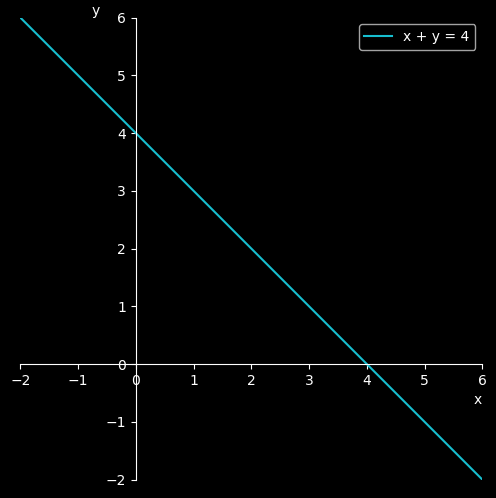

In [2]:
# A small helper to draw the line a*x + b*y = c.  (plotting only)
def plot_line(ax, a, b, c, color, label):
    x = np.linspace(-2, 6, 100)
    y = (c - a * x) / b        # solve the equation for y
    ax.plot(x, y, color=color, label=label)

fig, ax = plt.subplots(figsize=(6, 6))
plot_line(ax, 1, 1, 4, "tab:cyan", "x + y = 4")
center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("y", loc="top", rotation=0)
ax.set_xlim(-2, 6); ax.set_ylim(-2, 6); ax.set_aspect("equal"); ax.legend()
plt.show()

## 2. A system is an intersection: the three cases

Now add a second equation. The solution is where the two lines meet. Three situations cover everything:

- **one solution**: $x + y = 4$ and $2x - y = 3$ cross at a single point,
- **infinitely many**: $x + y = 4$ and $2x + 2y = 8$ are the *same* line (the second is just twice the first),
- **none**: $x + y = 4$ and $x + y = 3$ are **parallel** and never meet.

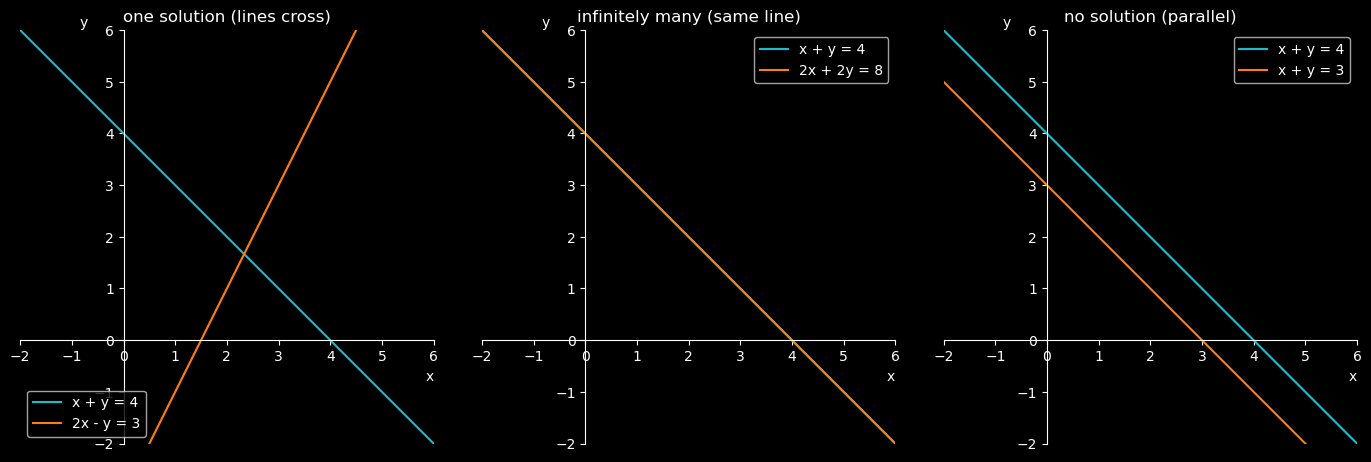

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# one solution
plot_line(axes[0], 1, 1, 4, "tab:cyan", "x + y = 4")
plot_line(axes[0], 2, -1, 3, "tab:orange", "2x - y = 3")
axes[0].set_title("one solution (lines cross)")

# infinitely many (same line)
plot_line(axes[1], 1, 1, 4, "tab:cyan", "x + y = 4")
plot_line(axes[1], 2, 2, 8, "tab:orange", "2x + 2y = 8")
axes[1].set_title("infinitely many (same line)")

# none (parallel)
plot_line(axes[2], 1, 1, 4, "tab:cyan", "x + y = 4")
plot_line(axes[2], 1, 1, 3, "tab:orange", "x + y = 3")
axes[2].set_title("no solution (parallel)")

for ax in axes:
    center_axes(ax)
    ax.set_xlabel("x", loc="right")
    ax.set_ylabel("y", loc="top", rotation=0)
    ax.set_xlim(-2, 6); ax.set_ylim(-2, 6); ax.set_aspect("equal"); ax.legend()
plt.tight_layout()
plt.show()

## 3. Reading the number of solutions

The picture tells you the answer before any algebra: crossing lines → one solution, one line drawn twice → infinitely many, parallel lines → none. When the equations are really the *same* line (case 2), one of them carries no new information, it is **redundant**.

## 4. Three variables: planes in 3D

With three variables, each equation $ax + by + cz = d$ is a flat **plane** floating in space. Three planes typically slice through one another at a single point, the unique solution. This is exactly the picture a whiteboard cannot draw, but we can rotate it here.

*(The 3D plotting code is just graphics, the point is that three planes meet at one spot.)*

<IPython.core.display.Math object>

+1x +1y +1z = 6   (should be 6)
+1x -1y +2z = 5   (should be 5)
+2x +1y -1z = 1   (should be 1)


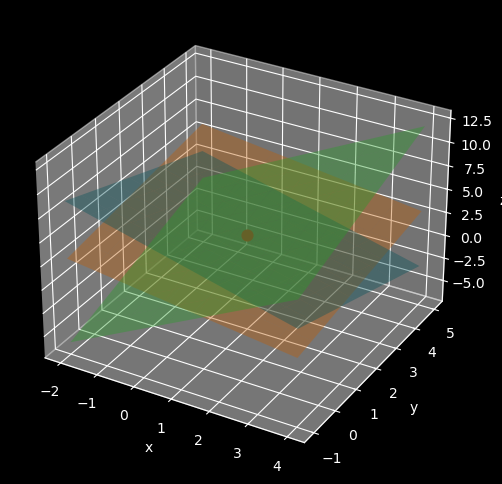

In [4]:
# Three planes:  x + y + z = 6,  x - y + 2z = 5,  2x + y - z = 1
coefficients = np.array([[1.0, 1, 1],
                         [1, -1, 2],
                         [2, 1, -1]])
right_hand_side = np.array([6.0, 5, 1])

# The three planes cross at a single point. The next two notebooks show how to *find* it;
# here we simply take the answer as given and look at the picture.
solution = np.array([1.0, 2.0, 3.0])
helpers.show(solution, label="where the three planes meet")

# check it really satisfies all three equations, one at a time
for row, d in zip(coefficients, right_hand_side):
    total = row[0] * solution[0] + row[1] * solution[1] + row[2] * solution[2]
    print(f"{row[0]:+.0f}x {row[1]:+.0f}y {row[2]:+.0f}z = {total:.0f}   (should be {d:.0f})")

# --- graphics: draw each plane as z = (d - a*x - b*y)/c over a grid ---
from mpl_toolkits.mplot3d import Axes3D
gx, gy = np.meshgrid(np.linspace(-2, 4, 10), np.linspace(-1, 5, 10))

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
colors = ["tab:cyan", "tab:orange", "tab:green"]
for row, d, color in zip(coefficients, right_hand_side, colors):
    a1, a2, a3 = row
    gz = (d - a1 * gx - a2 * gy) / a3
    ax.plot_surface(gx, gy, gz, alpha=0.4, color=color)
ax.scatter(*solution, color="red", s=60)     # the solution point
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
plt.show()

## 5. Summary

- A linear equation is a **line** (2D) or **plane** (3D); a **system** asks where they all intersect.
- **One** solution = lines cross; **none** = parallel; **infinitely many** = the same line (a redundant equation).
- Three planes usually meet at a single point, the unique solution.

Next: how to *find* that solution by hand, **substitution and elimination** (`U2-1_Systems-2_SubstitutionAndElimination`), then systematically with **Gaussian elimination** (`U2-1_Systems-3_GaussianElimination`).